# Instrument definition

In [1]:
import mcstasscript as ms

ess_w7 = ms.McStas_instr(
    "ESS_butterfly_W7",
    author="Bing Li",
    origin="DMSC",
    input_path="./ESS_butterfly_W7",
    output_path="./ESS_butterfly_W7/out",
)


bender = ess_w7.add_parameter(
    "int", "bender", value=1, comment="bender out = 0, bender in = 1"
)
b_rot = ess_w7.add_parameter(
    "double",
    "b_rot",
    value=-0.397881,
    comment="in [deg], rotation of the cold neutron bender = -atan(0.05/7.2), full deflection since endFlat=0",
)

# Declare section

In [2]:
frac = ess_w7.add_declare_var(
    "double",
    "frac",
    value=0.3,
    comment="Used in the Source component. Defines the statistical fraction of events"
    + "emitted from the cold part of the moderator, the value is determined later in the file"
    + " depending on the moderator type that was chosen",
)

# Initialize section

In [3]:
ess_w7.show_variables()

DECLARE VARIABLES 
type    variable name  array length  value  
------------------------------------------
double  frac                         0.3    



# Trace section

In [4]:
from mctrex.mcstas_components import add_components_to
from mctrex.params.params import component_dict

component_dict["source"].cold_frac = frac
component_dict["bender"].ROTATED = [0, b_rot, 0]

ess_w7 = add_components_to(ess_w7, component_dict)

ess_w7.show_parameters()

int    bender  = 1          // bender out = 0, bender in = 1
double b_rot   = -0.397881  // in [deg], rotation of the cold neutron bender = 
                                -atan(0.05/7.2), full deflection since endFlat=0 


In [5]:
ess_w7.backengine()


INFO: Using directory: "/Users/bingli/Documents/GitHub/mctrex/jupyter/visualize_guides/ESS_butterfly_W7/out"
INFO: Regenerating c-file: ESS_butterfly_W7.c
CFLAGS=
            
 The parameter rTopUpPar of bender is initialized 
 using a static {,,,} vector.
  -> Such static vectors support literal numbers ONLY.
  -> Any vector use of variables or defines must happen via a 
     DECLARE/INITIALIZE pointer.


 The parameter rTopDownPar of bender is initialized 
 using a static {,,,} vector.
  -> Such static vectors support literal numbers ONLY.
  -> Any vector use of variables or defines must happen via a 
     DECLARE/INITIALIZE pointer.


 The parameter rBotUpPar of bender is initialized 
 using a static {,,,} vector.
  -> Such static vectors support literal numbers ONLY.
  -> Any vector use of variables or defines must happen via a 
     DECLARE/INITIALIZE pointer.


 The parameter rBotDownPar of bender is initialized 
 using a static {,,,} vector.
  -> Such static vectors support lit

[]

In [6]:
# ess_w7.show_instrument()
# ess_w7.show_instrument(backend="pythreejs")

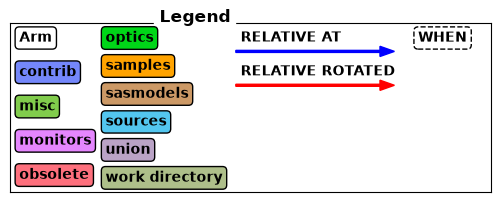

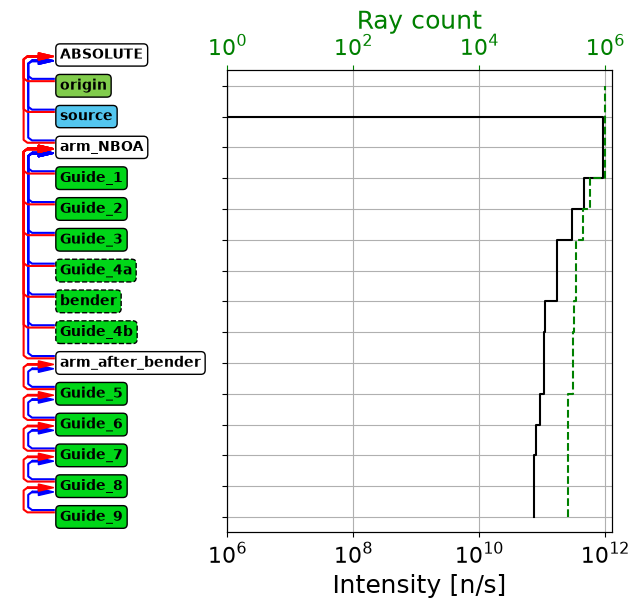

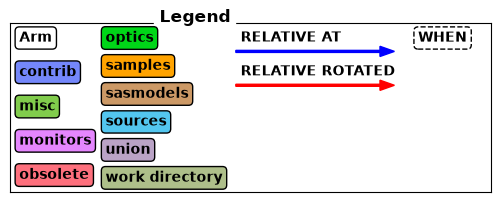

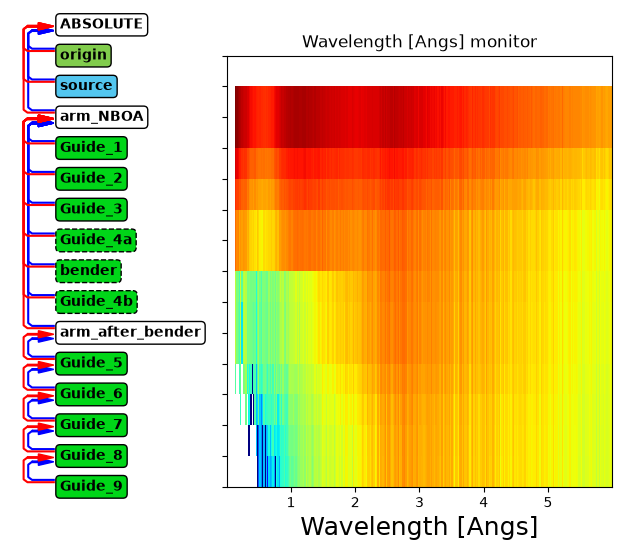

In [7]:
ess_w7.set_parameters(bender=1)
ess_w7.show_diagram(analysis=True)
ess_w7.show_diagram(variable="l", limits=[0, 6])

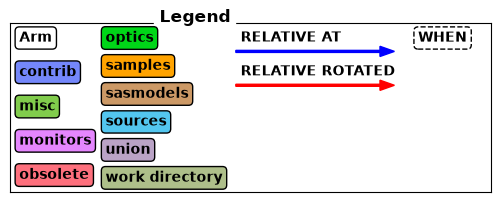

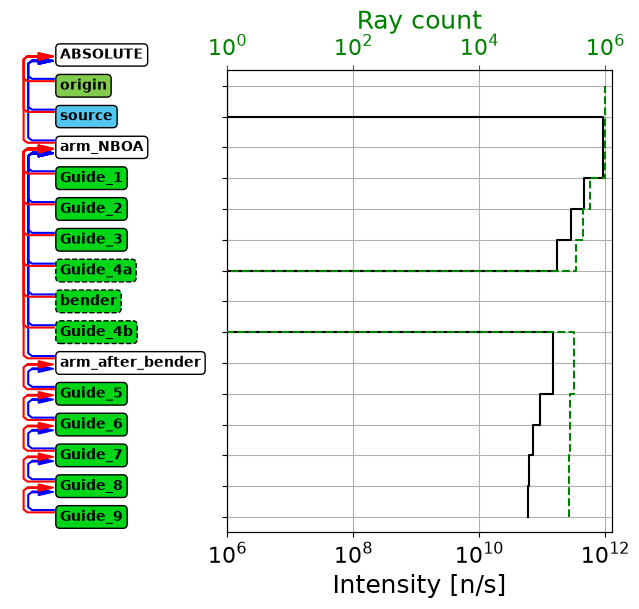

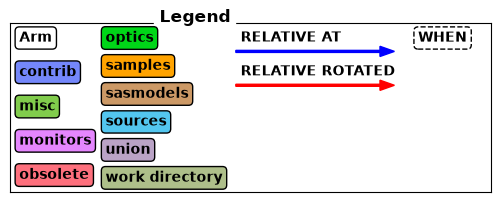

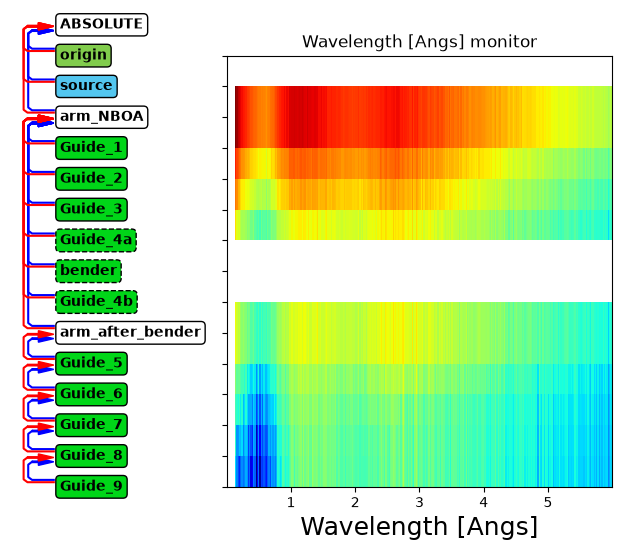

In [8]:
ess_w7.set_parameters(bender=0)
ess_w7.show_diagram(analysis=True)
ess_w7.show_diagram(variable="l", limits=[0, 6])

# Diagnostics

In [9]:
diag = ms.Diagnostics(ess_w7)

diag.settings(ncount=1e7, suppress_output=True, mpi="auto")
diag.show_settings()

Instrument settings:
  ncount:           1.00e+07
  mpi:              auto 
  output_path:      ESS_butterfly_W7/out
  run_path:         ./ESS_butterfly_W7
  package_path:     /Users/bingli/Documents/GitHub/mctrex/.pixi/envs/default/share/mcstas/resources
  executable_path:  /Users/bingli/Documents/GitHub/mctrex/.pixi/envs/default/bin
  executable:       mcrun
  force_compile:    True
  NeXus:            False
  save_comp_pars:   False


In [10]:
diag.clear_points()
diag.add_point(after="source")
# diag.add_point(before="Guide_1")
# diag.add_point(after="Guide_3")
diag.add_point(before="bender")
diag.add_point(after="bender")
#diag.add_point(after="Guide_6")

In [11]:
diag.set_parameters(bender=1)
diag.show_parameters()

int    bender  = 1          // bender out = 0, bender in = 1
double b_rot   = -0.397881  // in [deg], rotation of the cold neutron bender = 
                                -atan(0.05/7.2), full deflection since endFlat=0 


In [12]:
diag.run()

In [13]:
diag.clear_views()
diag.add_view("x", "y", bins=100)
# diag.add_view("vx", "vy", bins=200)
# diag.add_view("dx", "dy", bins=100)
# diag.add_view("l", bins=100)
# diag.add_view("t", bins=100)
diag.add_view("x", "l", bins=100)
#diag.add_view("t", "l", bins=100)
diag.add_view("l")

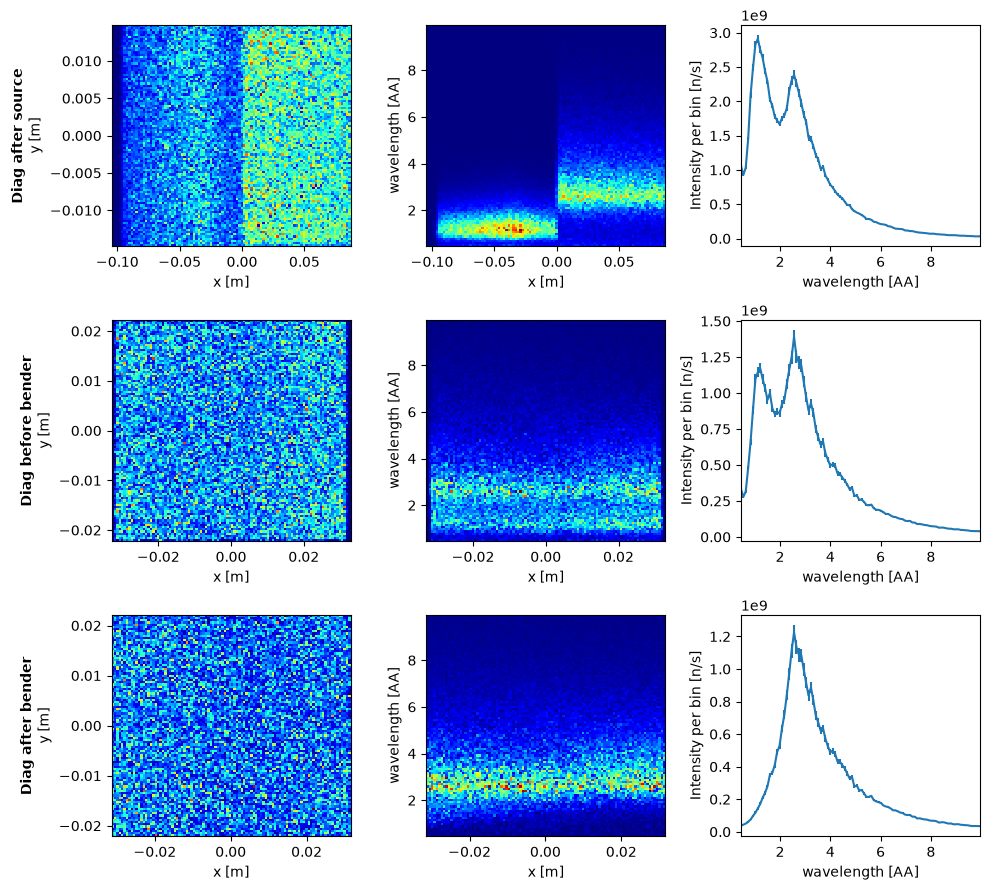

In [14]:
# %matplotlib widget
%matplotlib inline
diag.plot()

int    bender  = 0          // bender out = 0, bender in = 1
double b_rot   = -0.397881  // in [deg], rotation of the cold neutron bender = 
                                -atan(0.05/7.2), full deflection since endFlat=0 


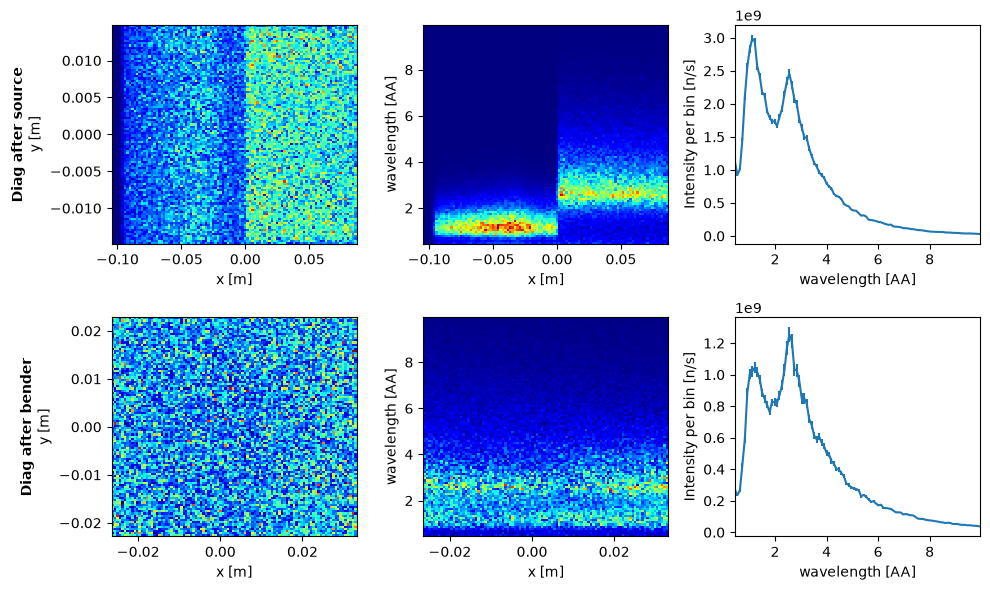

In [15]:
diag.set_parameters(bender=0)
diag.show_parameters()
diag.run()
diag.plot()